In [4]:
!pip install rapidfuzz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 29.8 MB/s eta 0:00:00


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from rapidfuzz import process
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.callbacks import EarlyStopping

In [10]:
df = pd.read_csv('dataset2_clean.csv')

df


,company_name,industry,job_title,skills_required,experience_level,employment_type,location,salary_range_usd,posted_date,company_size,tools_preferred,year,month
0,"hall, savage and walker",education,data scientist,"['pytorch', 'tensorflow', 'aws', 'c++', 'gcp']",entry,internship,"bowersberg, sk",135994-178112,2023-09-21,startup,"kdb+, mlflow, fastapi",2023,2023-09
1,snyder group,retail,ai product manager,"['tensorflow', 'gcp', 'cuda', 'r']",entry,contract,"jenniferburgh, ae",113791-138812,2023-09-21,large,langchain,2023,2023-09
2,wood llc,education,quant researcher,"['hugging face', 'flask', 'scikit-learn', 'gcp']",mid,internship,"north brooke, us",149745-219560,2023-09-21,large,"mlflow, fastapi",2023,2023-09
3,austin group,finance,data analyst,"['flask', 'fastapi', 'cuda', 'aws']",entry,full-time,"caseychester, sa",65884-114586,2023-09-22,startup,langchain,2023,2023-09
4,nelson plc,e-commerce,quant researcher,"['pytorch', 'pandas', 'tensorflow', 'azure', '...",entry,remote,"north linda, bg",72703-140316,2023-09-22,mid,"kdb+, scikit-learn",2023,2023-09
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,smith inc,tech,nlp engineer,"['aws', 'sql', 'excel']",entry,contract,"perezfurt, sz",103271-157584,2025-09-19,startup,"mlflow, langchain, fastapi",2025,2025-09
1996,"scott, nguyen and gomez",e-commerce,data scientist,"['keras', 'langchain', 'fastapi']",senior,contract,"west austinbury, sc",106470-120224,2025-09-19,startup,"fastapi, bigquery, tensorflow",2025,2025-09
1997,smith-cross,healthcare,ai product manager,"['flask', 'keras', 'pandas', 'cuda', 'pytorch'...",mid,remote,"anthonybury, et",67828-84015,2025-09-19,mid,fastapi,2025,2025-09
1998,"hernandez, collins and smith",retail,data scientist,"['scikit-learn', 'reinforcement learning', 'te...",entry,internship,"lake jessicaside, dj",100828-139590,2025-09-19,mid,"kdb+, langchain",2025,2025-09


In [7]:
df.columns

Index(['company_name', 'industry', 'job_title', 'skills_required',
       'experience_level', 'employment_type', 'location', 'salary_range_usd',
       'posted_date', 'company_size', 'tools_preferred', 'year', 'month'],
      dtype='object')

In [11]:
df = df.rename(columns={'posted_date': 'posting_date'})

In [12]:
df['posting_date'] = pd.to_datetime(df['posting_date'])

In [13]:
df['skills_required'] = df['skills_required'].str.split(',')

In [29]:
df["skills_required"] = df["skills_required"].str.lower()

df = df.drop_duplicates()

In [30]:
df = df.explode('skills_required')

In [15]:
df['skills_required'] = df['skills_required'].str.strip().str.lower()

In [35]:
import pandas as pd

def clean_skill(skill):
    skill = skill.replace("[", "")
    skill = skill.replace("]", "")
    skill = skill.replace("'", "")
    skill = skill.strip()
    return skill

df["skills_required"] = df["skills_required"].apply(clean_skill)

In [31]:
df


,company_name,industry,job_title,skills_required,experience_level,employment_type,location,salary_range_usd,posting_date,company_size,tools_preferred,year,month
0,"hall, savage and walker",education,data scientist,pytorch,entry,internship,"bowersberg, sk",135994-178112,2023-09-21,startup,"kdb+, mlflow, fastapi",2023,2023-09
0,"hall, savage and walker",education,data scientist,tensorflow,entry,internship,"bowersberg, sk",135994-178112,2023-09-21,startup,"kdb+, mlflow, fastapi",2023,2023-09
0,"hall, savage and walker",education,data scientist,aws,entry,internship,"bowersberg, sk",135994-178112,2023-09-21,startup,"kdb+, mlflow, fastapi",2023,2023-09
0,"hall, savage and walker",education,data scientist,c++,entry,internship,"bowersberg, sk",135994-178112,2023-09-21,startup,"kdb+, mlflow, fastapi",2023,2023-09
0,"hall, savage and walker",education,data scientist,gcp,entry,internship,"bowersberg, sk",135994-178112,2023-09-21,startup,"kdb+, mlflow, fastapi",2023,2023-09
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1998,"hernandez, collins and smith",retail,data scientist,tensorflow,entry,internship,"lake jessicaside, dj",100828-139590,2025-09-19,mid,"kdb+, langchain",2025,2025-09
1999,reilly plc,education,ml engineer,aws,senior,internship,"bennettfurt, iq",140820-232170,2025-09-19,startup,"scikit-learn, bigquery, langchain",2025,2025-09
1999,reilly plc,education,ml engineer,azure,senior,internship,"bennettfurt, iq",140820-232170,2025-09-19,startup,"scikit-learn, bigquery, langchain",2025,2025-09
1999,reilly plc,education,ml engineer,c++,senior,internship,"bennettfurt, iq",140820-232170,2025-09-19,startup,"scikit-learn, bigquery, langchain",2025,2025-09


In [50]:
df = df.drop(columns=[
    'company_name',
    'industry',
    'experience_level',
    'employment_type',
    'location',
    'salary_range_usd',
    'company_size',
    'tools_preferred',
    'year'
])

In [51]:
df.head()

,job_title,skills_required,posting_date,month
0,data scientist,pytorch,2023-09-21,2023-09
0,data scientist,tensorflow,2023-09-21,2023-09
0,data scientist,aws,2023-09-21,2023-09
0,data scientist,c++,2023-09-21,2023-09
0,data scientist,gcp,2023-09-21,2023-09


In [32]:
df['month'] = df['posting_date'].dt.to_period('M')

skill_trend = df.groupby(['month','skills_required']).size().reset_index(name='count')

In [33]:
pivot = skill_trend.pivot(
    index='month',
    columns='skills_required',
    values='count'
).fillna(0)

In [34]:
pivot.columns.tolist()

['aws',
 'azure',
 'c++',
 'cuda',
 'excel',
 'fastapi',
 'flask',
 'gcp',
 'hugging face',
 'keras',
 'langchain',
 'mlflow',
 'numpy',
 'pandas',
 'power bi',
 'python',
 'pytorch',
 'r',
 'reinforcement learning',
 'scikit-learn',
 'sql',
 'tensorflow']

In [36]:
from rapidfuzz import process

skills = pivot.columns.tolist()

def find_skill(query):

    query = query.lower()

    best_match = process.extractOne(
        query,
        skills
    )

    if best_match and best_match[1] > 60:
        return best_match[0]

    return None

Skill ditemukan: python


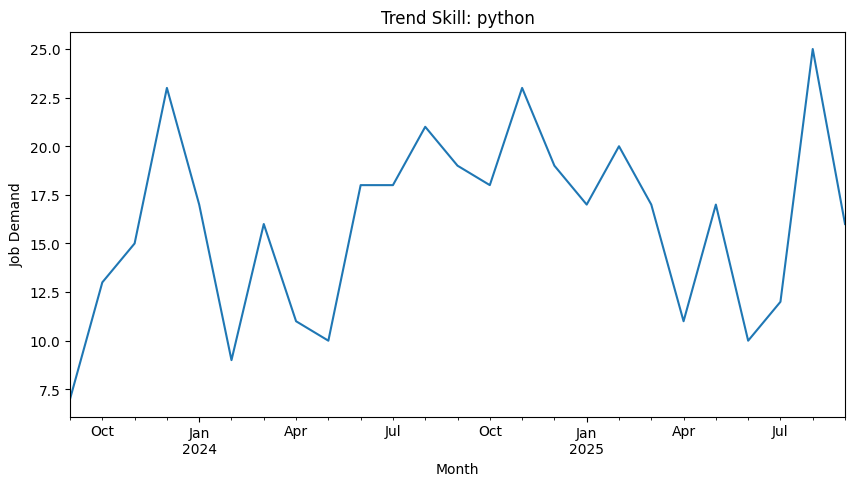

In [49]:
query = "python"

skill = find_skill(query)

if skill is None:
    print("Skill tidak ditemukan")
else:
    print("Skill ditemukan:", skill)

    plt.figure(figsize=(10,5))

    pivot[skill].plot()

    plt.title(f"Trend Skill: {skill}")
    plt.xlabel("Month")
    plt.ylabel("Job Demand")

    plt.show()

In [41]:
def get_skill_trend(query):

    skill = find_skill(query)

    return pivot[skill]

In [42]:
import numpy as np

data = pivot.values

X = data[:-1]
y = data[1:]

print(X.shape, y.shape)

(24, 22) (24, 22)


In [43]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    Dense(64, activation='relu', input_shape=(pivot.shape[1],)),
    Dense(pivot.shape[1])
])

model.compile(
    optimizer='adam',
    loss='mse'
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [44]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

data_scaled = scaler.fit_transform(pivot.values)

X = data_scaled[:-1]
y = data_scaled[1:]

In [45]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='loss',
    patience=20,
    restore_best_weights=True
)


In [52]:
history = model.fit(
    X,
    y,
    epochs=500,
    batch_size=1,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/500
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.3042
Epoch 2/500
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1128
Epoch 3/500
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0897
Epoch 4/500
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0845
Epoch 5/500
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0718
Epoch 6/500
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0795
Epoch 7/500
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0674
Epoch 8/500
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0711 
Epoch 9/500
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0944 
Epoch 10/500
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0595 
Epoch 11/500
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0725 
Epoch 12/500
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0537 
Epoch 13/500
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0501 
Epoch 14/500
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0557 
Epoch 15/500
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.04

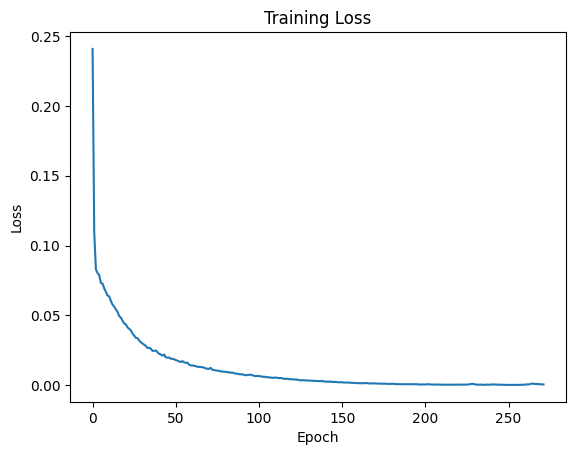

In [53]:
plt.plot(history.history['loss'])
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [54]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(pivot.values)

last_month_scaled = data_scaled[-1].reshape(1,-1)

prediction_scaled = model.predict(last_month_scaled)

prediction = scaler.inverse_transform(prediction_scaled)

prediction = prediction.flatten()

predicted = pd.Series(prediction, index=pivot.columns)

print(predicted.sort_values(ascending=False))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
skills_required
power bi                  21.344946
fastapi                   18.693867
gcp                       18.515343
python                    17.082365
tensorflow                16.844351
numpy                     16.689793
pandas                    16.207134
langchain                 16.157841
flask                     15.896124
scikit-learn              15.859590
aws                       15.846864
hugging face              15.635982
c++                       14.928615
azure                     14.656609
pytorch                   14.184143
mlflow                    13.238656
reinforcement learning    12.916451
keras                     12.665294
excel                      8.248584
r                          6.489287
sql                        6.000916
cuda                       3.093549
dtype: float32


In [55]:
df.to_csv("dataset2_clean.csv")

In [56]:
import joblib

joblib.dump(scaler, "scaler.save")

['scaler.save']

In [59]:
model.save("dataset2_clean.keras")